In [ ]:
# final edition of correlation models from sklearn, on full data. take heavily from the init_corr_models files
# TODO

In [ ]:
# importing modules and packages 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, mean_absolute_error 
from sklearn.preprocessing import OneHotEncoder
from sklearn import linear_model
from sklearn.tree import DecisionTreeRegressor
import numpy as np

In [ ]:
df = pd.read_csv('Daily_Means_Through_2022.csv')

In [ ]:
df

In [ ]:
print(df.dtypes)

# date to datetime (though we change it again after so idk if this is even smart)
df['Date'] = pd.to_datetime(df['date'])
df_pivot = df.pivot_table(index=['Date', 'site', 'depth'], columns='parameter', values='measure', aggfunc='mean')
df_pivot.reset_index(inplace=True)
df_pivot.drop(columns=['DO_pct'], inplace=True)
df_pivot = df_pivot[df_pivot["depth"] != "mid"]
df_pivot

In [ ]:
df_new = df_pivot.pivot_table(index=['Date', 'site'], 
                          columns='depth', 
                          values=['DO_mg/L', 'Density_g/cm3', 'Depth_m', 'Salinity_ppt', 'Temp_C', 'pH', 'Chl_ug/L', "Turb_NTU"])
df_new.columns = [f"{pos}_{col}" for col, pos in df_new.columns]

# Reset index to make it a regular dataframe
df_pivot = df_new.reset_index()

df_pivot

In [ ]:
# if a row has both bottom and surface density, add a column for the difference
df_pivot['stratification'] = df_pivot['bottom_Density_g/cm3'] - df_pivot['surface_Density_g/cm3']
df_pivot

In [ ]:
# one hot encoding depth, site
#df = pd.get_dummies(df_pivot, columns=['depth', 'site'], drop_first=True)
df = pd.get_dummies(df_pivot, columns=['site'], drop_first=True)
# turn date into a number
df['Date'] = df['Date'].map(pd.Timestamp.toordinal)

In [ ]:
# get nans
df.dropna(inplace=True, subset=["bottom_DO_mg/L", "surface_DO_mg/L"])
print(df.isna().sum())
print(len(df))

In [ ]:
X = df.drop(columns=['bottom_DO_mg/L', 'surface_DO_mg/L'])
y = df['bottom_DO_mg/L']
y_surface = df['surface_DO_mg/L']

# train test split - test data is taken 
X_train = X[X["Date"] < 738000]
X_test = X[X["Date"] >= 738000]
y_train = y[X["Date"] < 738000]
y_test = y[X["Date"] >= 738000]
y_surface_train = y_surface[X["Date"] < 738000]
y_surface_test = y_surface[X["Date"] >= 738000]
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
y_train


In [ ]:
import xgboost as xgb

In [ ]:
# For regression
reg = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='mape', learning_rate=0.1, max_depth=5, subsample=0.7)
reg.fit(X_train, y_train)

reg1 = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='mape', learning_rate=0.1, max_depth=5, subsample=0.7)
reg1.fit(X_train, y_surface_train)

In [ ]:
# Regression
y_pred_reg = reg.predict(X_test)
y_pred_reg1 = reg1.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Regression evaluation
rmse = mean_squared_error(y_test, y_pred_reg)
mae = mean_absolute_error(y_test, y_pred_reg)
mape_bottom = np.mean(np.abs((y_test - y_pred_reg) / y_test))
print("MAPE: %f" % (mape_bottom) +"%")
print("RMSE: %f" % (rmse)) 
print("MAE: %f" % (mae))

rmse = mean_squared_error(y_surface_test, y_pred_reg1)
mae = mean_absolute_error(y_surface_test, y_pred_reg1)
mape_surface = np.mean(np.abs((y_surface_test - y_pred_reg1) / y_surface_test))
print("for surface")
print("MAPE: %f" % (mape_surface) +"%")
print("RMSE: %f" % (rmse))
print("MAE: %f" % (mae))

In [ ]:
# get combined mape weighted
mape_combined = (mape_bottom * len(y_test) + mape_surface * len(y_surface_test)) / (len(y_test) + len(y_surface_test))
print("Combined MAPE: %f" % (mape_combined) +"%")

In [ ]:
# # Define the hyperparameter grid
# param_grid = {
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.1, 0.01, 0.001],
#     'subsample': [0.5, 0.7, 1]
# }

# # Create the XGBoost model object
# xgb_model = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='mape')

# # Create the GridSearchCV object
# grid_search = GridSearchCV(xgb_model, param_grid, cv=5, verbose=True)

# # Fit the GridSearchCV object to the training data
# grid_search.fit(X_train, y_train)

# # Print the best set of hyperparameters and the corresponding score
# print("Best set of hyperparameters: ", grid_search.best_params_)
# print("Best score: ", grid_search.best_score_)

In [ ]:
y_pred_reg

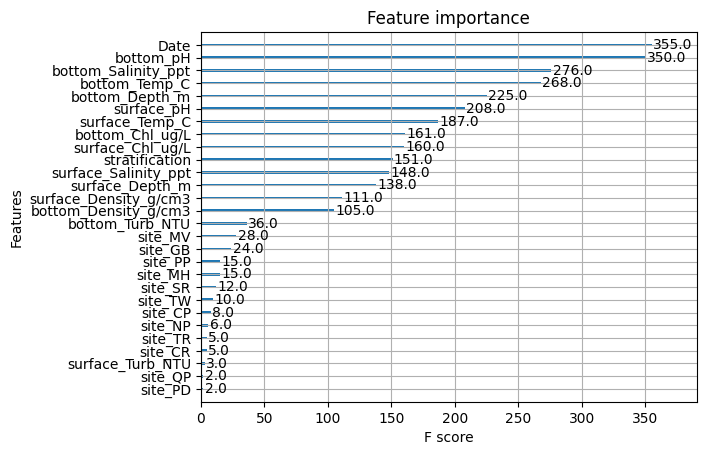

In [ ]:
xgb.plot_importance(reg, importance_type='weight')

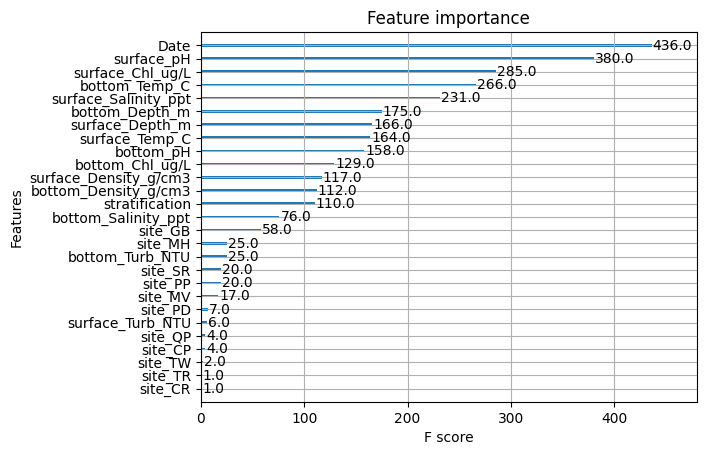

In [ ]:
xgb.plot_importance(reg1, importance_type='weight')

In [ ]:
df

In [ ]:
import shap

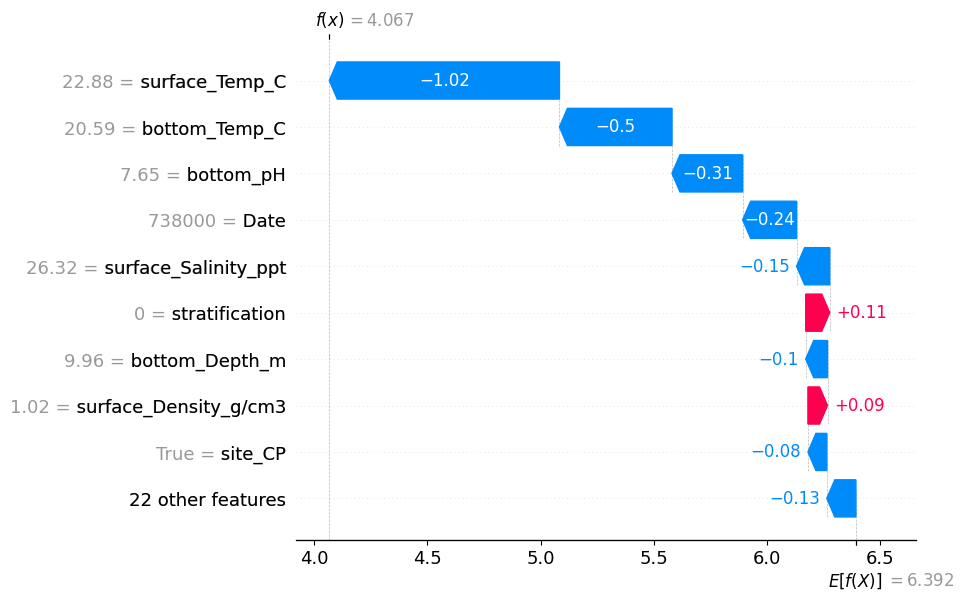

In [ ]:
explainer = shap.Explainer(reg)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.initjs()
# shap.plots.force(shap_values[1000:2000])

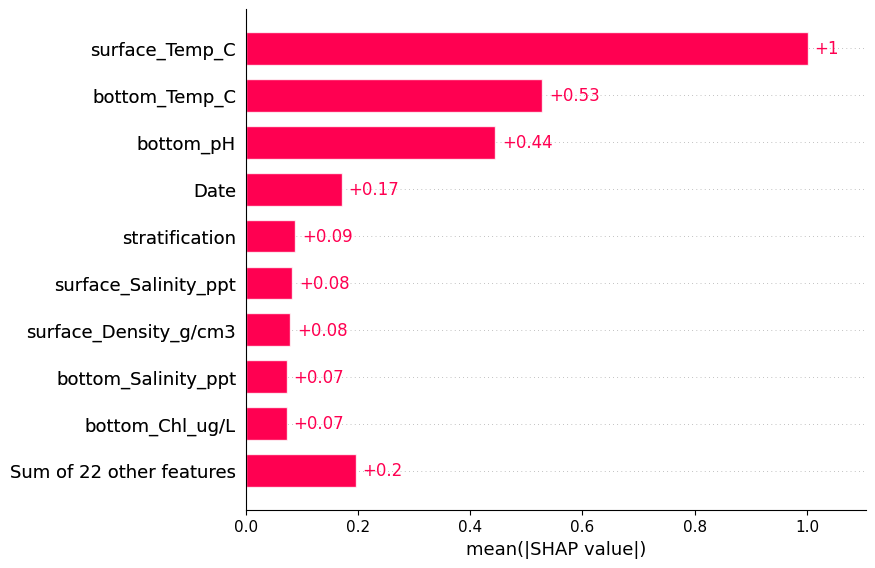

In [ ]:
shap.plots.bar(shap_values)

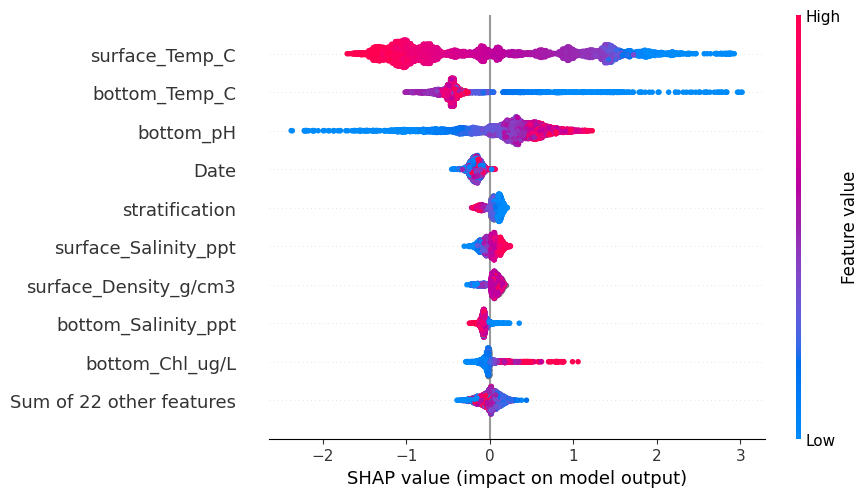

In [ ]:
shap.plots.beeswarm(shap_values)

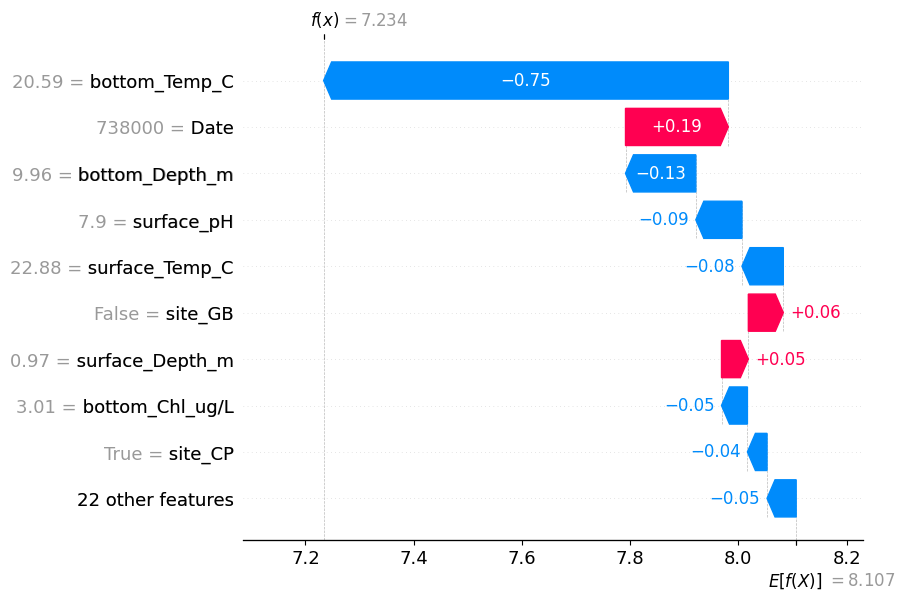

In [ ]:
explainer = shap.Explainer(reg1)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0])

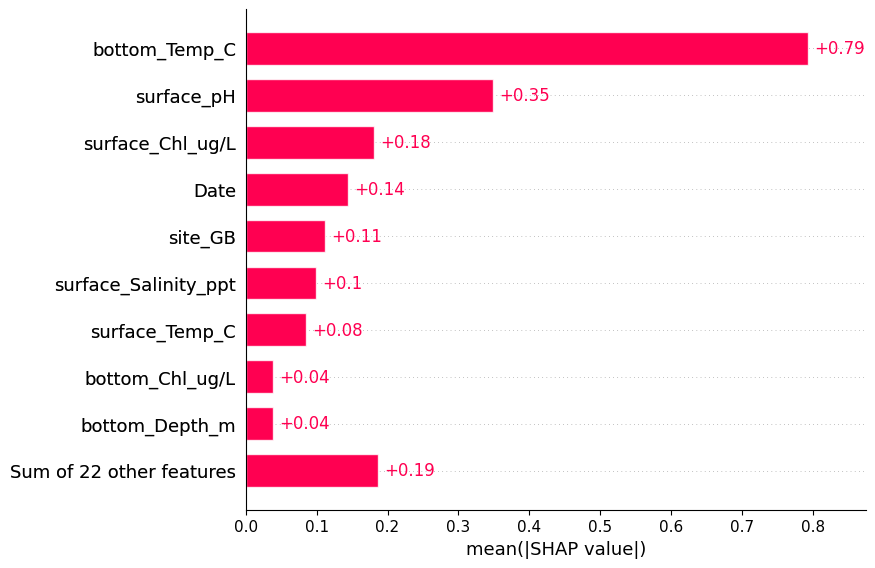

In [ ]:
shap.plots.bar(shap_values)

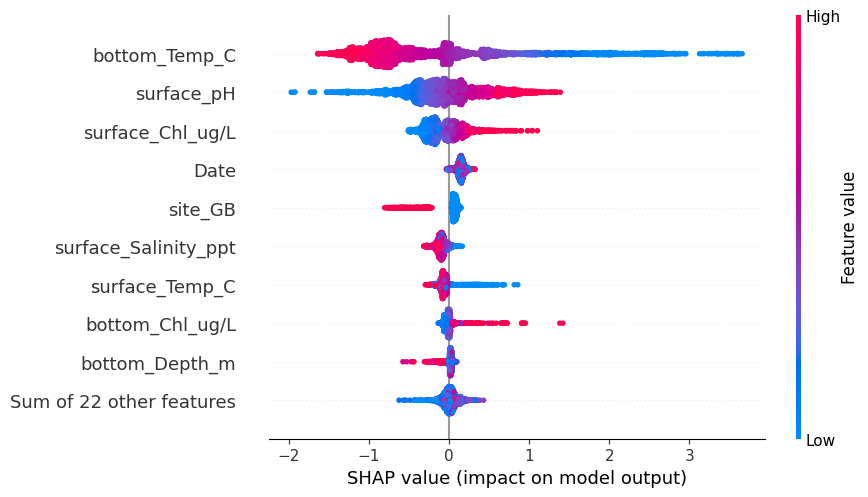

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
from shap import TreeExplainer
from sklearn.tree import export_graphviz
import graphviz


In [ ]:
explainer = TreeExplainer(reg)
explanation = explainer(X_test)

shap_values = explanation.values

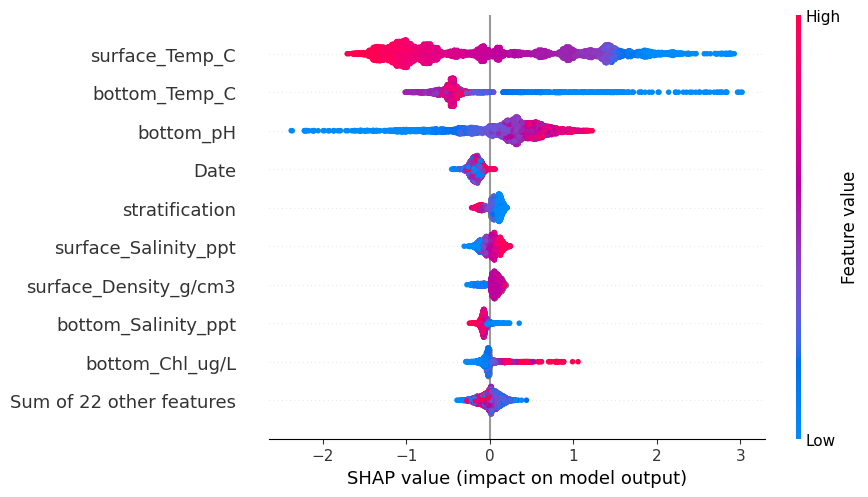

In [ ]:
shap.plots.beeswarm(explanation)

In [ ]:
explainer = TreeExplainer(reg)
shap_values = explainer.shap_values(X_test)
shap.plots.bar(shap_values)

In [ ]:
# trying cross validation

#new_bottom_reg = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='mape', learning_rate=0.1, max_depth=5, subsample=0.7)

params = {
    'objective': 'reg:squarederror',  # Regression objective
    'eval_metric': 'mape',  # Root Mean Squared Error
    'max_depth': 5,
    'learning_rate': 0.1,  # Learning rate
    'subsample': 0.7,
}

dtrain = xgb.DMatrix(X, label=y)

cv_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,  # Maximum boosting rounds
    nfold=5,  # 5-fold CV
    metrics=['rmse', "mape"],
    early_stopping_rounds=10,  # Stops if performance doesn't improve in 10 rounds
    seed=42
)

print(cv_results)

In [ ]:
params = {
    'objective': 'reg:squarederror',  # Regression objective
    'eval_metric': 'mape',  # Root Mean Squared Error
    'max_depth': 5,
    'learning_rate': 0.1,  # Learning rate
    'subsample': 0.7,
}

dtrain = xgb.DMatrix(X, label=y_surface)

cv_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,  # Maximum boosting rounds
    nfold=5,  # 5-fold CV
    metrics=['rmse', "mape"],
    early_stopping_rounds=10,  # Stops if performance doesn't improve in 10 rounds
    seed=42
)

print(cv_results)

In [ ]:
from xgboost import plot_tree

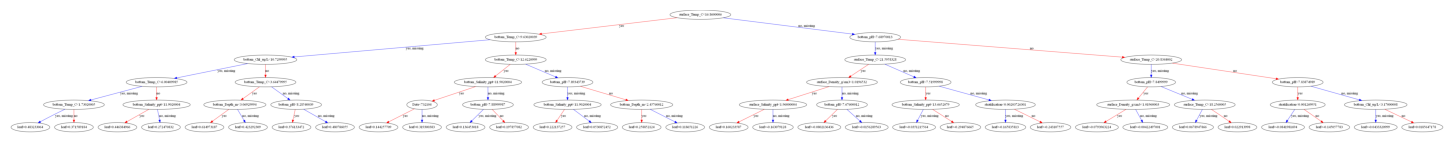

In [ ]:
fig = plot_tree(reg, num_trees=1)
# resize
#fig.set_size_inches(100, 100)
plt.gcf().set_size_inches(18.5, 18.5)

fig

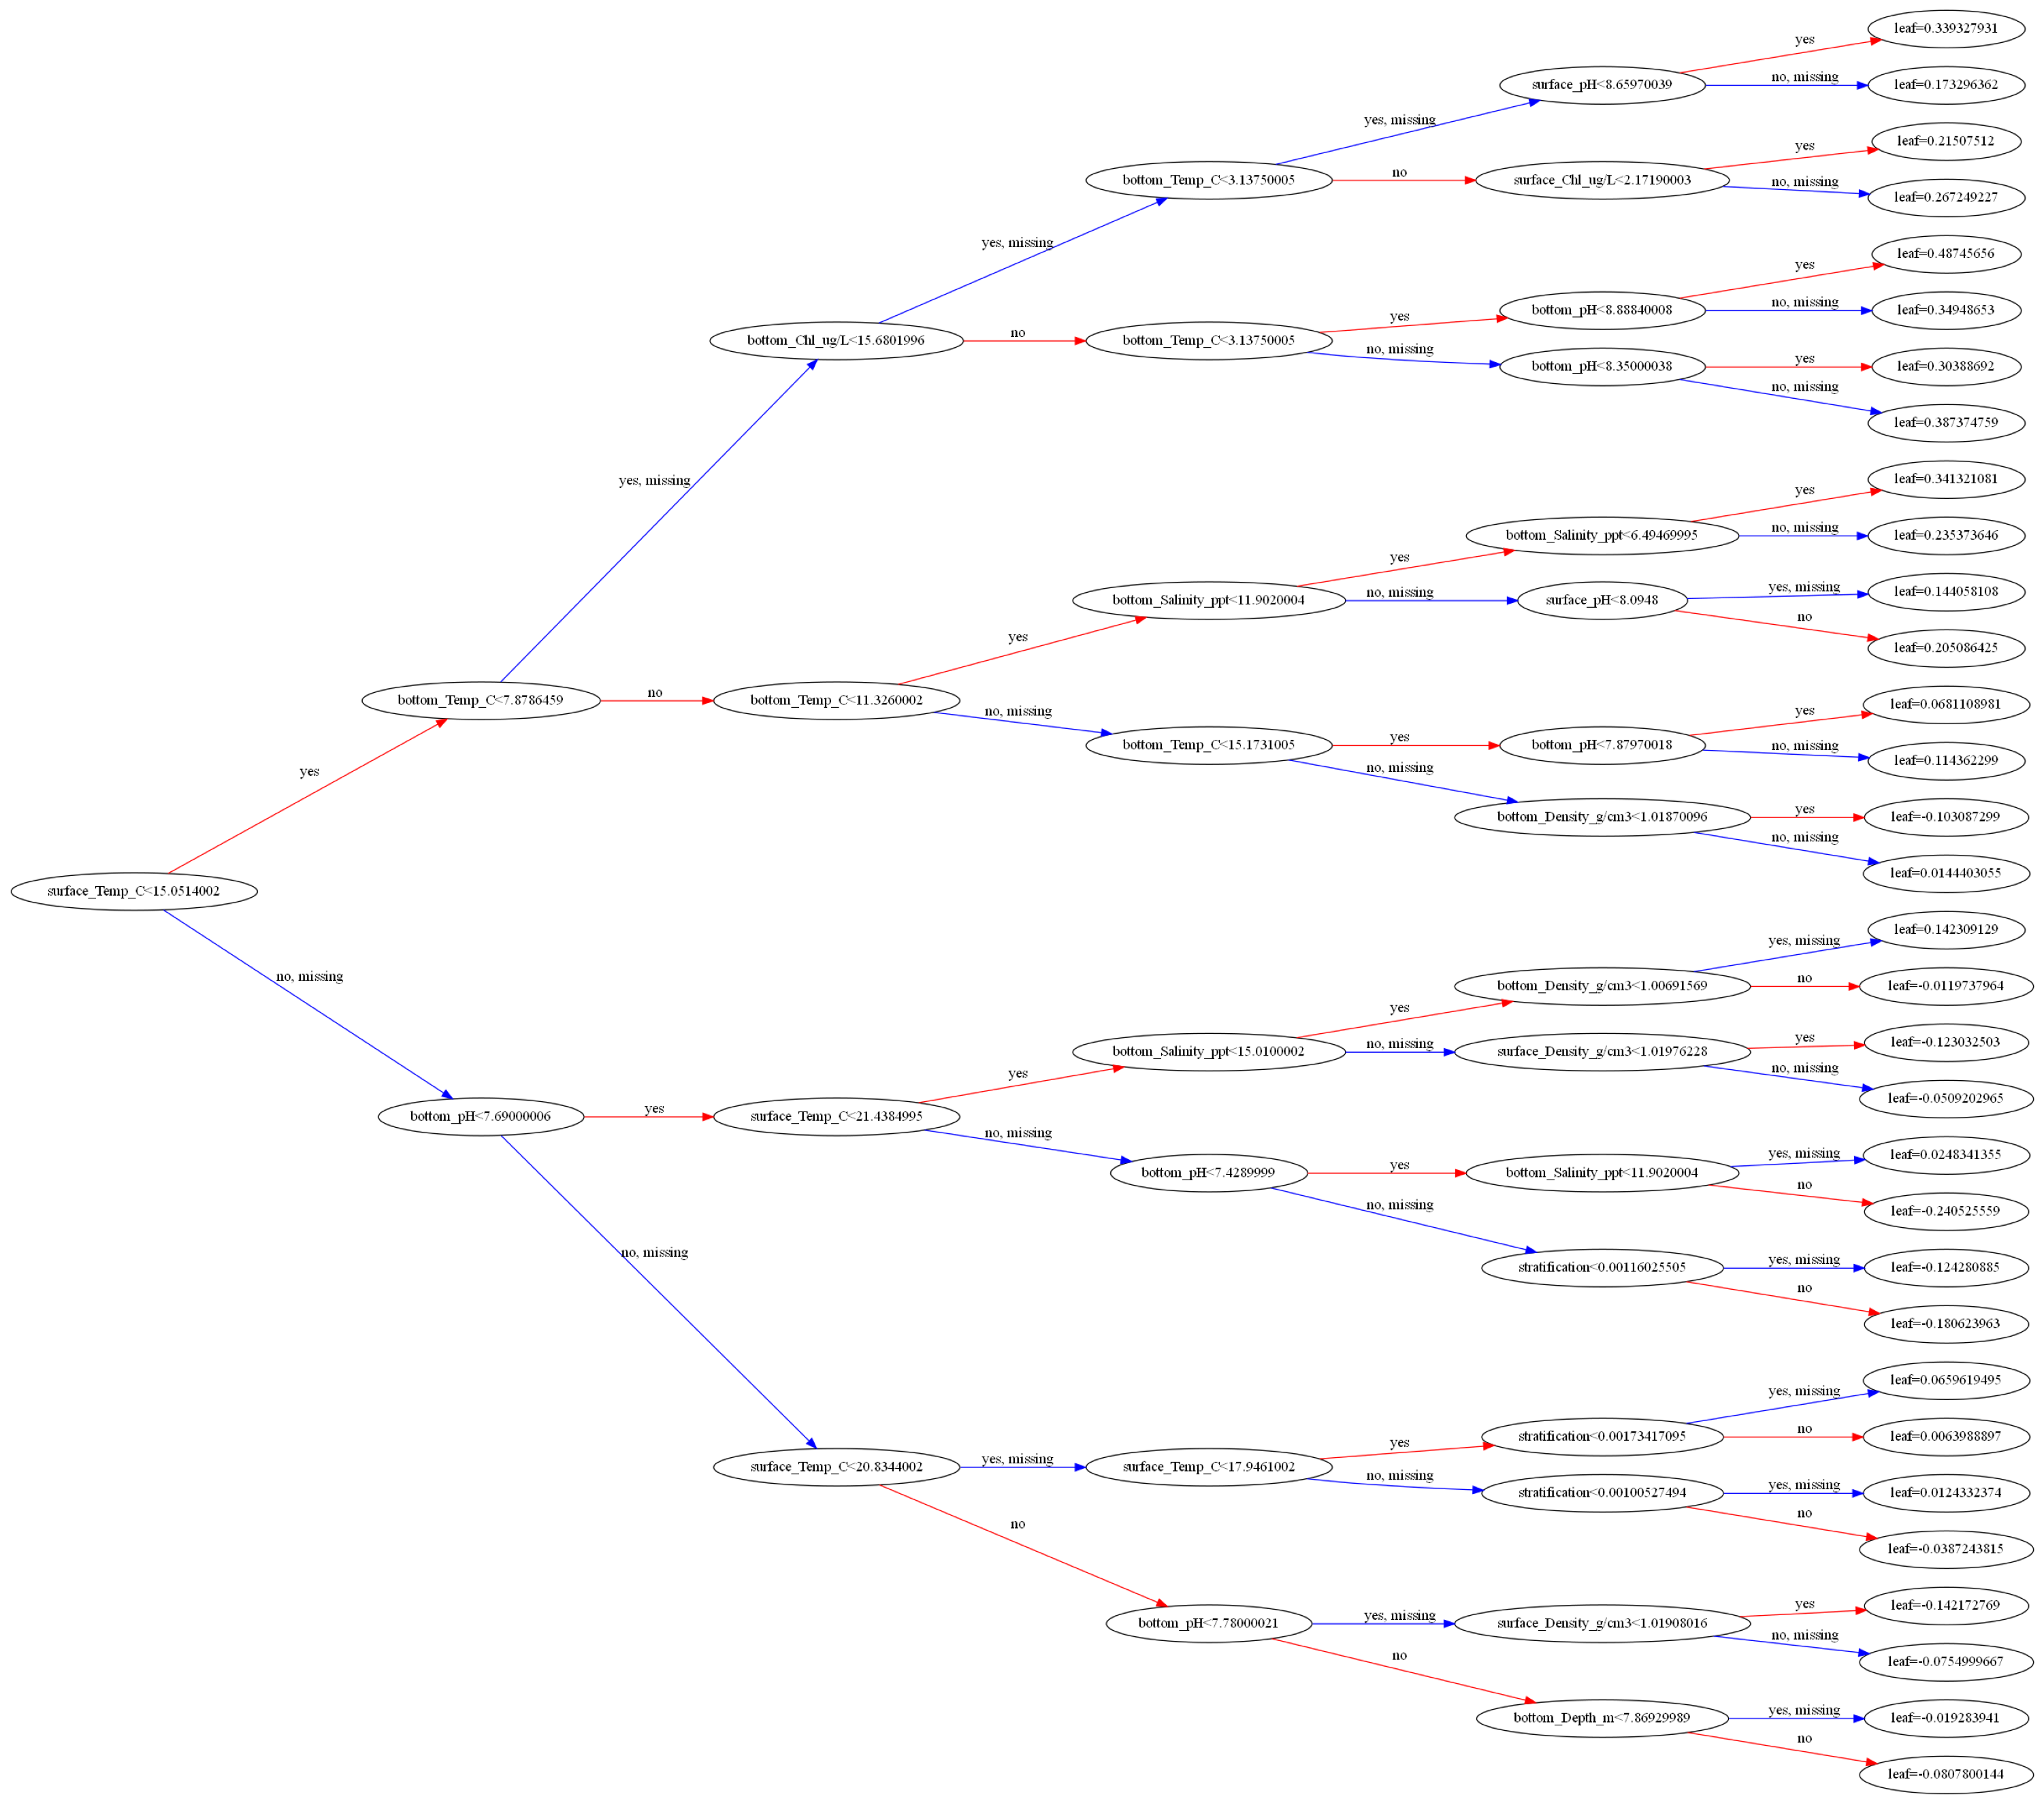

In [ ]:
fig, ax = plt.subplots(figsize=(50, 50))
xgb.plot_tree(reg, num_trees=4, ax=ax, rankdir='LR')
plt.gcf().set_size_inches(38.5, 38.5)

plt.show()